# 📖 LangChain RAG로 《데미안》 다시 읽기

PDF 한 권을 **Document Loader → Text Splitter → Embedding → VectorStore(Chroma) → Retriever → QA** 순서로 연결해,
책 내용에 근거한 질의응답 파이프라인을 만듭니다. 마지막에는 검색 방식(**similarity vs mmr**)을 바꿔 결과를 비교합니다.

| 단계 | 하는 일 | 확인하는 출력 |
|---|---|---|
| Step 0 | 설치, 경로·키·환경 설정 | 작업 폴더, 패키지 버전 |
| Step 1 | PDF 로드 | 페이지 수, 첫 페이지 |
| Step 2 | 토큰 기준 분할 | chunk 수, 길이 분포 |
| Step 3 | 임베딩 | 임베딩 차원, 유사도 예시 |
| Step 4 | Chroma 저장 + Retriever | 검색 결과 |
| Step 5 | 질의응답 + 출처 검증 | 답변, 출처 문단, 검증 결과 |
| Step 6 | similarity vs mmr 비교 | 비교표, 그래프 |
| Step 7 | 결론·회고 | — |

> **실행 순서**: 설치 셀 실행 → `Kernel → Restart` → 설치 셀은 건너뛰고 아래부터 순서대로 실행
> **생성 파일은 전부 `langchain_demian` 폴더 안에만** 저장됩니다: `Demian.pdf`, `chroma_db/`, `results/`

---
## Step 0. 설치와 준비

In [8]:
# ⚙️ 패키지 설치 — 처음 한 번만 실행
# %pip 는 '지금 이 노트북 커널'의 파이썬에 설치합니다 (!pip 은 다른 파이썬 환경에 깔릴 수 있음).
# 설치가 끝나면 Kernel → Restart 한 번. 이미 import 된 옛 버전과 섞이면 오류가 납니다.
%pip install -q -U langchain langchain-openai langchain-community langchain-core langchain-text-splitters langchain-chroma langchain-classic pypdf tiktoken gdown pandas matplotlib

ERROR: Could not install packages due to an OSError: [WinError 32] 다른 프로세스가 파일을 사용 중이기 때문에 프로세스가 액세스 할 수 없습니다: 'c:\\Users\\singf\\Desktop\\venv\\Lib\\site-packages\\langchain_classic\\agents\\format_scratchpad\\openai_functions.py'
Check the permissions.


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 경로 고정
터미널이 상위 폴더(`Naiffel`)에서 실행되더라도, **모든 파일이 `langchain_demian` 안에만 생기도록** 절대경로로 고정하고 작업 폴더를 이동합니다.

In [9]:
from pathlib import Path
import os

# 📁 작업 폴더 (절대경로) — 환경 요인: PC가 바뀌면 이 한 줄만 수정
BASE_DIR = Path(r"C:\Users\singf\Desktop\Naiffel\langchain_demian")
BASE_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(BASE_DIR)   # 혹시 상대경로로 저장되는 파일이 있어도 작업 폴더로 떨어지게 함

PDF_PATH    = BASE_DIR / "Demian.pdf"
CHROMA_DIR  = BASE_DIR / "chroma_db"      # 벡터 DB 저장 위치 (커널을 재시작해도 재사용)
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)
METRICS_CSV = RESULTS_DIR / "metrics.csv"  # 실험 결과 누적 저장

# 🔑 API 키 파일은 상위 폴더에 있음 — '읽기만' 하고 상위 폴더에는 아무것도 쓰지 않습니다
KEY_PATH = BASE_DIR.parent / "open-ai_api.txt"

print("현재 작업 폴더:", Path.cwd())
assert Path.cwd().resolve() == BASE_DIR.resolve(), "작업 폴더가 다릅니다! BASE_DIR 을 확인하세요."

현재 작업 폴더: C:\Users\singf\Desktop\Naiffel\langchain_demian


In [10]:
# 키는 코드에 적지 않고 파일에서 읽어 '환경 변수'로만 등록합니다. 화면에도 출력하지 않습니다.
os.environ["OPENAI_API_KEY"] = KEY_PATH.read_text(encoding="utf-8").strip()
os.environ["ANONYMIZED_TELEMETRY"] = "False"   # Chroma 사용 통계 전송 끄기 (경고 메시지 감소)
print("API 키 로드 완료")

API 키 로드 완료


### 재현성 · 환경 기록
LLM은 `temperature=0`으로 고정해 답변 흔들림을 줄입니다. (API 특성상 완전히 같은 답을 보장하지는 않습니다)

In [11]:
import sys, platform, random
import importlib.metadata as md
import numpy as np

SEED = 67
random.seed(SEED); np.random.seed(SEED)

print("Python :", sys.version.split()[0], "|", platform.platform())
for pkg in ["langchain", "langchain-openai", "langchain-chroma", "chromadb", "pypdf", "tiktoken"]:
    try:
        print(f"{pkg:17}: {md.version(pkg)}")
    except md.PackageNotFoundError:
        print(f"{pkg:17}: 미설치")

Python : 3.12.13 | Windows-11-10.0.26200-SP0
langchain        : 1.4.2
langchain-openai : 1.6.6
langchain-chroma : 1.1.0
chromadb         : 1.5.9
pypdf            : 6.19.0
tiktoken         : 0.14.0


### 실험 설정 + 시각화 설정
바꿀 수 있는 값은 전부 이 셀에 모았습니다. 여기만 수정하면 아래 전체에 반영됩니다.

In [12]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

# 🔧 조절 가능한 값들
LLM_MODEL     = "gpt-4o"                   # 비용을 줄이려면 "gpt-4o-mini"
EMBED_MODEL   = "text-embedding-3-small"   # 1536차원·저렴. 더 정밀하게는 "text-embedding-3-large"(3072차원)
CHUNK_SIZE    = 500     # chunk 최대 길이 (토큰 기준)
CHUNK_OVERLAP = 50      # 이웃 chunk 와 겹치는 토큰 수 (약 10%)
TOP_K         = 4       # LLM 에 넘길 chunk 개수
FETCH_K       = 20      # mmr 전용: 후보 20개를 먼저 뽑고 그중 서로 다른 4개를 고름

### Text splitter 준비: 토큰 길이 함수
글자 수(`len`)가 아니라 **토큰 수**로 길이를 잽니다. 모델의 입력 한도와 비용이 모두 토큰 단위이기 때문입니다.

In [13]:
import tiktoken
tokenizer = tiktoken.get_encoding("cl100k_base")   # GPT-4 계열·OpenAI 임베딩이 쓰는 토크나이저

def tiktoken_len(text: str) -> int:
    return len(tokenizer.encode(text))

print(tiktoken_len("Emil Sinclair meets Max Demian."), "토큰")

8 토큰


---
## Step 1. Document Loader
`PyPDFLoader`로 PDF를 읽습니다. **페이지 1장이 Document 1개**가 되며, `metadata["page"]`에 페이지 번호가 붙습니다. 이 번호가 나중에 답변의 출처 표시에 쓰입니다.

In [14]:
import gdown

# 파일이 없거나 비어 있을 때만 받습니다.
# output 을 '절대경로'로 지정 → 터미널 위치와 무관하게 langchain_demian 폴더에 저장
if not PDF_PATH.exists() or PDF_PATH.stat().st_size == 0:
    gdown.download(id="1oYqBihNheRgOH2JQ0zaXXLHuSuY27IPq", output=str(PDF_PATH), quiet=False)

print(f"{PDF_PATH.name}: {PDF_PATH.stat().st_size/1024/1024:.1f} MB  →  {PDF_PATH}")

Downloading...
From: https://drive.google.com/uc?id=1oYqBihNheRgOH2JQ0zaXXLHuSuY27IPq
To: C:\Users\singf\Desktop\Naiffel\langchain_demian\Demian.pdf
100%|██████████| 5.68M/5.68M [00:00<00:00, 8.38MB/s]

Demian.pdf: 5.4 MB  →  C:\Users\singf\Desktop\Naiffel\langchain_demian\Demian.pdf


In [15]:
from langchain_community.document_loaders import PyPDFLoader

pages = PyPDFLoader(str(PDF_PATH)).load()
print("📄 페이지 수:", len(pages))
print("메타데이터 예시:", pages[0].metadata)
print("-" * 60)
print(pages[0].page_content[:800])

C:\Users\singf\AppData\Local\Temp\ipykernel_20712\231338190.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


📄 페이지 수: 182
메타데이터 예시: {'producer': 'Adobe Acrobat Standard DC 19 Paper Capture Plug-in', 'creator': 'ScanFix(TM) Enhanced', 'creationdate': '2015-09-10T01:40:29+00:00', 'moddate': '2019-01-30T17:47:47+01:00', 'source': 'C:\\Users\\singf\\Desktop\\Naiffel\\langchain_demian\\Demian.pdf', 'total_pages': 182, 'page': 0, 'page_label': '1'}
------------------------------------------------------------
DEMIAN 
• 
Downloaded from https://www.holybooks.com


---
## Step 2. Text Splitter
`RecursiveCharacterTextSplitter`는 `문단(\n\n) → 줄(\n) → 공백 → 글자` 순으로 경계를 찾아 자르기 때문에, 문장이 중간에 잘리는 일이 적습니다.

**설정 이유**
- `chunk_size=500` 토큰: 소설의 한두 문단 분량입니다. 인물 묘사나 사건 하나가 한 chunk 안에 담기기 충분하고, `k=4`개를 합쳐도 약 2,000토큰이라 LLM 입력에 여유가 있습니다.
- `chunk_overlap=50` (약 10%): 경계에 걸친 문장이 양쪽 chunk에 모두 남도록 해서 문맥이 끊기는 것을 줄입니다.

In [16]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=tiktoken_len,   # 토큰 기준으로 자름
)
docs = text_splitter.split_documents(pages)   # 페이지 번호 메타데이터가 각 chunk 에도 따라감

lens = [tiktoken_len(d.page_content) for d in docs]
print(f"✂️ chunk 수: {len(docs)}  |  평균 {np.mean(lens):.0f} 토큰, 최대 {max(lens)} 토큰")
print(f"전체 토큰: {sum(lens):,}  →  임베딩 예상 비용 ≈ ${sum(lens)/1e6*0.02:.4f}")   # 3-small 기준

✂️ chunk 수: 182  |  평균 398 토큰, 최대 456 토큰
전체 토큰: 72,349  →  임베딩 예상 비용 ≈ $0.0014


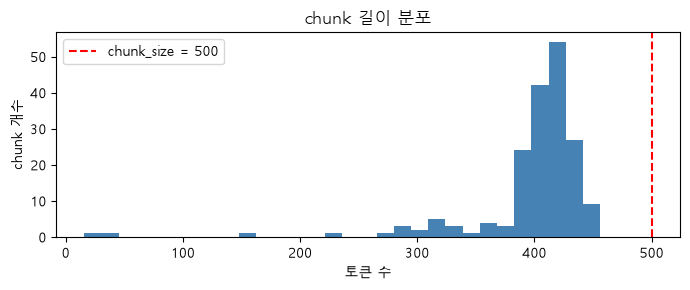

In [17]:
plt.figure(figsize=(7, 3))
plt.hist(lens, bins=30, color="steelblue")
plt.axvline(CHUNK_SIZE, color="red", ls="--", label=f"chunk_size = {CHUNK_SIZE}")
plt.title("chunk 길이 분포"); plt.xlabel("토큰 수"); plt.ylabel("chunk 개수"); plt.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / "chunk_length_hist.png", dpi=120); plt.show()

> 💡 **결과 해석**: chunk 수(182)가 페이지 수(182)와 같고, 가장 긴 chunk도 456토큰입니다. **모든 페이지가 500토큰보다 짧아서 splitter가 실제로는 한 번도 자르지 않았다**는 뜻입니다. 즉 이번 설정에서는 `chunk = 페이지 1장`이고, `chunk_overlap=50`도 적용될 일이 없었습니다. 분할 효과를 보려면 `chunk_size`를 페이지보다 작게(예: 200~300) 잡거나, 페이지를 합친 뒤 나눠야 합니다.

---
## Step 3. Vector Embedding
`text-embedding-3-small`은 가격이 저렴하고, 영문 소설 검색에는 이 정도 성능으로 충분합니다. 먼저 chunk 하나를 임베딩해 차원을 확인합니다.

In [18]:
from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model=EMBED_MODEL)

vec = embedding_model.embed_query(docs[0].page_content)   # chunk 1개만 임베딩 (비용 거의 0)
print("🔢 임베딩 차원:", len(vec))
print("앞 5개 값:", np.round(vec[:5], 4))

🔢 임베딩 차원: 1536
앞 5개 값: [ 0.0041 -0.02   -0.0081  0.0017  0.0153]


**임베딩이 '의미'를 담는지 간단히 확인**: 뜻이 가까운 문장일수록 코사인 유사도가 높게 나와야 합니다.
질의는 `embed_query`, 문서는 `embed_documents`로 임베딩합니다. 일부 모델은 이 둘을 다르게 처리하기 때문에 구분해서 씁니다.

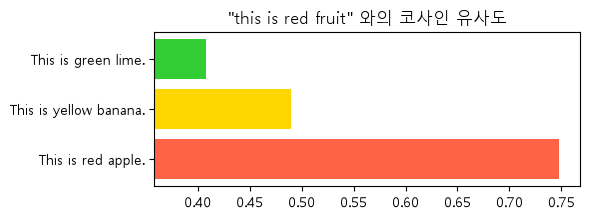

In [19]:
def cos_sim(a, b):
    a, b = np.array(a), np.array(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

sentences = ["This is red apple.", "This is yellow banana.", "This is green lime."]
query = "this is red fruit"
sims = [cos_sim(v, embedding_model.embed_query(query)) for v in embedding_model.embed_documents(sentences)]

plt.figure(figsize=(6, 2.3))
plt.barh(sentences, sims, color=["tomato", "gold", "limegreen"])
plt.xlim(min(sims) - 0.05, max(sims) + 0.02)
plt.title(f'"{query}" 와의 코사인 유사도'); plt.tight_layout(); plt.show()

---
## Step 4. VectorStore(Chroma) + Retriever
chunk 전체를 임베딩해 Chroma에 저장합니다. `persist_directory`를 지정했으므로 **두 번째 실행부터는 디스크에서 바로 불러옵니다** (임베딩 비용·시간 0).
컬렉션 이름에 chunk 설정값을 넣어 두어, 설정을 바꾸면 자동으로 새 DB가 만들어집니다.

In [20]:
# ⏱ 첫 실행만 약 30초~1분 (전체 chunk 임베딩). 이후 실행은 즉시 로드
from langchain_chroma import Chroma

COLLECTION = f"demian_cs{CHUNK_SIZE}_ov{CHUNK_OVERLAP}"
db = Chroma(collection_name=COLLECTION, embedding_function=embedding_model,
            persist_directory=str(CHROMA_DIR))

if db._collection.count() == 0:
    db.add_documents(docs)
    print("새로 임베딩하여 저장했습니다")
print(f"🗄️ 저장된 벡터 수: {db._collection.count()}  |  위치: {CHROMA_DIR}")

새로 임베딩하여 저장했습니다
🗄️ 저장된 벡터 수: 182  |  위치: C:\Users\singf\Desktop\Naiffel\langchain_demian\chroma_db


**Retriever 설정 이유**
- `search_type="mmr"` (Maximal Marginal Relevance): 질문과 관련 있으면서도 **서로 겹치지 않는** chunk를 고릅니다. 소설은 같은 인물이나 장면이 여러 번 반복해서 묘사되는데, `similarity`는 거의 같은 내용의 chunk를 여러 개 가져올 수 있습니다. mmr은 이 중복을 줄여, 제한된 k개 안에 더 다양한 근거를 담는 것을 기대합니다.
- `k=4`: 근거가 부족하지 않을 만큼 가져오되, 관련 없는 chunk가 섞여 답변을 흐리지 않도록 적당히 잡았습니다.
- `fetch_k=20`: mmr이 다양성을 고를 후보 풀의 크기입니다.

In [21]:
retriever = db.as_retriever(search_type="mmr", search_kwargs={"k": TOP_K, "fetch_k": FETCH_K})

test_q = "What does Demian look like?"
print(f"🔍 질문: {test_q}\n")
for i, d in enumerate(retriever.invoke(test_q), 1):
    print(f"[{i}] p.{d.metadata.get('page', -1) + 1} | {d.page_content[:220].replace(chr(10), ' ')}...\n")

🔍 질문: What does Demian look like?

[1] p.54 | DEMIAN  with a feeling of nausea, I noticed Demian's expression.  He had not thrust himself to the front but stood right  at the back, looking elc!gant and at ease as usual. His  glance seemed directed at the horse's hea...

[2] p.90 | DEMIAN  Why had it only just dawned on me I It wu Demian'•  face.  Later I often comP9Xed the face on the paper with  Demian's features as l remembered them. They were  certainly, though similar, not the same. But beyond...

[3] p.34 | DEMIAN  character and have some significance. But I merely knew  that Demian's mother was reported to be very wealthy.  It was also said that neither she nor her son ever  attended church. One boy wondered whether they m...

[4] p.71 | THE THIEF  eyes were fixed on that pale, stone mask, speJibound, and  I felt that here was the real Demian I What he had been  before when he had gone around and chatted with me  was only IJ,alf of him, a person who for ...



---
## Step 5. Question Answering
`RetrievalQA`(`chain_type="stuff"`)는 검색된 chunk를 프롬프트에 그대로 채워 넣고 답하게 합니다. `return_source_documents=True`를 주면 근거로 쓴 chunk도 함께 돌려받습니다.

**출처 검증 방법**: 답변과 출처 문단을 gpt-4o에게 다시 보여주고, 답변의 모든 내용이 출처에 있는지 `SUPPORTED / PARTIAL / UNSUPPORTED`로 판정하게 합니다. 사람이 직접 확인한 결과는 아래 표에 기록합니다.

질문 4번은 **책에 없는 내용**입니다. 모델이 지어내지 않고 "모른다"고 답하는지 확인하기 위해 넣었습니다.

In [22]:
import re
import pandas as pd
from datetime import datetime
from langchain_openai import ChatOpenAI
from langchain_classic.chains.retrieval_qa.base import RetrievalQA

llm = ChatOpenAI(model=LLM_MODEL, temperature=0.0)

QUESTIONS = [
    "What does Demian look like?",
    "Who is Franz Kromer and why is Sinclair afraid of him?",
    "What is Abraxas?",
    "What is Sinclair's favorite food?",   # 책에 없는 내용 → 지어내는지 확인
]

def make_qa(search_type):
    kwargs = {"k": TOP_K} | ({"fetch_k": FETCH_K} if search_type == "mmr" else {})
    return RetrievalQA.from_chain_type(
        llm, chain_type="stuff",
        retriever=db.as_retriever(search_type=search_type, search_kwargs=kwargs),
        return_source_documents=True)

In [23]:
# ── 출처 검증 (LLM 판정) ──
JUDGE_PROMPT = """You are checking an answer produced by a RAG system.
Sources:
{sources}

Answer:
{answer}

Is every claim in the answer supported by the sources? If the answer says it does not know
and the sources indeed lack that information, count it as SUPPORTED.
Reply in exactly this format:
VERDICT: SUPPORTED | PARTIAL | UNSUPPORTED
REASON: <one short sentence in Korean>"""

def judge(answer, srcs):
    sources = "\n\n".join(f"[{i}] {d.page_content}" for i, d in enumerate(srcs, 1))
    out = llm.invoke(JUDGE_PROMPT.format(sources=sources, answer=answer)).content
    m = re.search(r"VERDICT:\s*(SUPPORTED|PARTIAL|UNSUPPORTED)", out)
    reason = out.split("REASON:")[-1].strip()
    return (m.group(1) if m else "?"), reason

# ── 검색 품질 지표 (비교 실험용, 추가 비용은 임베딩 몇 번뿐) ──
def retrieval_metrics(question, srcs):
    q = np.array(embedding_model.embed_query(question))
    D = np.array(embedding_model.embed_documents([d.page_content for d in srcs]))
    q, D = q / np.linalg.norm(q), D / np.linalg.norm(D, axis=1, keepdims=True)
    relevance = float((D @ q).mean())                  # 질문과의 평균 유사도  (↑ 좋음)
    S, n = D @ D.T, len(D)
    redundancy = float((S.sum() - n) / (n * (n - 1))) if n > 1 else 1.0   # chunk끼리 평균 유사도 (↓ 다양)
    pages_ = sorted({d.metadata.get("page", -1) + 1 for d in srcs})
    return relevance, redundancy, pages_

In [24]:
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SCORE = {"SUPPORTED": 1.0, "PARTIAL": 0.5, "UNSUPPORTED": 0.0}

def show(q, ans, srcs, verdict, reason, n_chars=300):
    display(Markdown(f"#### ❓ {q}\n**답변:** {ans}\n\n**출처 검증:** `{verdict}` — {reason}"))
    for i, d in enumerate(srcs, 1):   # n_chars: 출처 문단을 몇 글자까지 보여줄지
        print(f"  [출처 {i}] p.{d.metadata.get('page', -1) + 1}: {d.page_content[:n_chars].replace(chr(10), ' ')}...")

def run_experiment(search_type, verbose=True):
    qa, rows = make_qa(search_type), []
    for q in QUESTIONS:
        res = qa.invoke({"query": q})
        ans, srcs = res["result"], res["source_documents"]
        rel, red, pgs = retrieval_metrics(q, srcs)
        verdict, reason = judge(ans, srcs)
        if verbose:
            show(q, ans, srcs, verdict, reason)
        rows.append(dict(run_id=RUN_ID, search_type=search_type, k=TOP_K, chunk_size=CHUNK_SIZE,
                         llm=LLM_MODEL, question=q, answer=ans, pages=str(pgs),
                         n_unique_pages=len(pgs), query_relevance=round(rel, 4),
                         redundancy=round(red, 4), verdict=verdict,
                         grounded=SCORE.get(verdict, np.nan), judge_reason=reason))
    df = pd.DataFrame(rows)
    # 💾 실험마다 누적 저장 → 커널이 죽어도 결과가 남음
    df.to_csv(METRICS_CSV, mode="a", header=not METRICS_CSV.exists(), index=False, encoding="utf-8")
    return df

In [25]:
# ⏱ 약 1분 (질문 4개 × [답변 1회 + 검증 1회])
df_mmr = run_experiment("mmr")

#### ❓ What does Demian look like?
**답변:** Demian is described as having a face that is neither distinctly masculine nor childish, neither old nor young, but almost timeless, bearing the mark of other periods of history. His appearance is unique and different from others, with an almost feminine element. He is compared to an animal, a spirit, or an image, and his face is described as stone-like, handsome, cold, and dead, yet with an alarming secret life within. His presence is described as having an aura of quiet emptiness and celestial space.

**출처 검증:** `SUPPORTED` — 모든 주장들이 출처에 의해 뒷받침됩니다.

  [출처 1] p.54: DEMIAN  with a feeling of nausea, I noticed Demian's expression.  He had not thrust himself to the front but stood right  at the back, looking elc!gant and at ease as usual. His  glance seemed directed at the horse's head, and again it  . showed that deep, quiet, almost fanatical yet passionate  abs...
  [출처 2] p.90: DEMIAN  Why had it only just dawned on me I It wu Demian'•  face.  Later I often comP9Xed the face on the paper with  Demian's features as l remembered them. They were  certainly, though similar, not the same. But beyond all  doubt, it was Demian.  Once one evening in early summer the sun was slant­...
  [출처 3] p.34: DEMIAN  character and have some significance. But I merely knew  that Demian's mother was reported to be very wealthy.  It was also said that neither she nor her son ever  attended church. One boy wondered whether they might  not be Jews but they could equally well be Mohamme­ dans. Tales were also ...
  [출처 4] p.71: THE THIEF  eyes were fixed o

#### ❓ Who is Franz Kromer and why is Sinclair afraid of him?
**답변:** Franz Kromer is a character in the book "Demian" by Hermann Hesse. He is depicted as a bully and a ringleader who exerts control over Sinclair and other boys. Sinclair is afraid of Kromer because he feels uncomfortable in his presence and fears Kromer's wrath. Kromer has a commanding presence and gives orders that Sinclair and the other boys feel compelled to obey. Sinclair's fear is compounded by the fact that he feels like an outsider among the group and worries that Kromer, as well as the other boys, would disown and desert him if it came to it.

**출처 검증:** `SUPPORTED` — 모든 주장들이 주어진 출처에 의해 뒷받침됩니다.

  [출처 1] p.10: DEMIAN  as ringleader we climbed down the river bank near the  bridge and hid ourselves away from the world under the  first arch. The narrow strip between the vaulted bridge  and the lazily flowing rlver consisted of nothing but  general rubbish and broken pots, tangles of rusty barbed  wire and si...
  [출처 2] p.43: CAIN  thing about it to anyone. Not a word! You're making  me very unhappy."  "'You can rely on me, Sinclair. You can tell me your  seaet some other time."  "Never, never," I cried loudly.  "Just as you like. All I mean is that perhaps you may  tell me more about it later. Voluntarily of course! You...
  [출처 3] p.175: THE BEGINNING OF THE END  sure of that. I didn't worry you about it before, but since  then I've come across new signs on three occasions. It's  not going to be the end of the world, an earthquake or  revolution, but war. You will see the effect on people.  They will acclaim it with enthusiasm; ever...
  [출처 4] p.167: EVA  if they were fragment

#### ❓ What is Abraxas?
**답변:** Abraxas is a concept mentioned in the context of mystical and philosophical teachings. It is described as having a deeper significance beyond being merely an evil spirit, as some might have considered it in ancient times. In the narrative, Abraxas represents a step forward in the progress to self-knowledge and embodies a mixture of ecstasy and horror, male and female, sacred and profane, innocence and guilt. It symbolizes a complex and multifaceted understanding of existence, combining elements of both good and evil, and is associated with the inner journey and personal transformation.

**출처 검증:** `SUPPORTED` — 모든 주장들이 출처에 의해 뒷받침됩니다.

  [출처 1] p.110: DEMIAN  doesn't get to know about Abraxas by chance, mark my  words. I'll tell you more iJbout him. I know a little."  He fell silent and pushed his chair back. When I  looked expectantly at him, he pulled a face.  · "Not here! Another time. Here, take some!"  So saying he delved into the pocket of ...
  [출처 2] p.100: DEMIAN  tected. I had also ex~nted with,e staring-out  technique and had found it effective. In Demian'• time  I had not pulled it ol but now I realized that one could  bring about a great de~ just by thinking and intensiw  staring.  So I was sitting now miles away from Herodotus and  school when th...
  [출처 3] p.118: VI  Jacob and The Angel  It is impossible to recount briefly what I learned from  the eccentric musician about Abraxas. The most impor­ tant thing was that it meant a step forward in the  progress to self-knowledge. I was at that time an unusual  youth .for my eighteen years, precocious in a hundred...
  [출처 4] p.103: 1' H E BI RD ST RU G G L

#### ❓ What is Sinclair's favorite food?
**답변:** I don't know. The provided context does not mention Sinclair's favorite food.

**출처 검증:** `SUPPORTED` — 제공된 문맥에는 Sinclair의 좋아하는 음식에 대한 정보가 없습니다.

  [출처 1] p.153: EVA  form of a reply and a fulfilment. I saw a host of pictures  ftashing past my mind's eye-the house at home with  the old coat-of-arms above the door arch, the boy Demian  sketching the carving, myself as a boy, terribly involved  in the evil spell of my enemy Kromer, myself in adoles­ cence, in ...
  [출처 2] p.117: THB BI-lt,D STRUGGLES OUT OF THE EGG  are so willing to renounce any idea of flying and prefer  to sttoll quietly along the pavement and obey the law.  But you are not one of these. You have higher aspirations  as behoves a man of spirit. And look I You discover the  ~acle that you are gradually win...
  [출처 3] p.175: THE BEGINNING OF THE END  sure of that. I didn't worry you about it before, but since  then I've come across new signs on three occasions. It's  not going to be the end of the world, an earthquake or  revolution, but war. You will see the effect on people.  They will acclaim it with enthusiasm; ever...
  [출처 4] p.64: DEMIAN  Mount Golgotha, a

### ✍️ 출처 대조 결과
위 출력의 답변과 출처 문단을 대조한 결과입니다.

| 질문 | LLM 판정 | 직접 확인 | 메모 |
|---|---|---|---|
| Demian의 외모 | SUPPORTED | ✅ | "돌 같은 가면(stone mask)", 차갑고 시간을 초월한 얼굴 등의 묘사가 p.71·p.90 출처와 일치합니다. 다만 p.34는 Demian 어머니에 대한 소문이라 외모와 관련이 적습니다. |
| Franz Kromer | SUPPORTED | ⚠️ | 불량배 우두머리라는 설명은 p.10과 맞습니다. 하지만 Sinclair가 Kromer를 두려워하는 **핵심 이유(거짓말을 빌미로 한 협박)가 빠졌습니다.** 출처 4개 중 p.167·p.175는 책 후반부라 질문과 관계가 없습니다. |
| Abraxas | SUPPORTED | ✅ | 자기 인식으로 나아가는 단계, 선과 악·성과 속이 뒤섞인 존재라는 설명이 p.110·p.118 출처와 맞습니다. |
| 좋아하는 음식 (책에 없음) | SUPPORTED | ✅ | "모른다"고 답했고 지어내지 않았습니다. 검색된 출처 4개도 음식과 관계가 없었습니다. |

> **정리**: LLM 판정은 4개 모두 SUPPORTED였지만, Kromer 질문은 "출처와 어긋나지 않음"과 "질문에 충분히 답함"이 다를 수 있음을 보여줍니다. 판정 프롬프트가 **충실도만 보고 완결성은 보지 않기** 때문입니다.

---
## Step 6. 설정 비교: similarity vs mmr
같은 질문, 같은 `k=4`로 `search_type`만 바꿔 비교합니다.

| 지표 | 의미 | 좋은 방향 |
|---|---|---|
| query_relevance | 가져온 chunk와 질문의 평균 유사도 | ↑ |
| redundancy | 가져온 chunk끼리의 평균 유사도 (중복 정도) | ↓ |
| n_unique_pages | 근거가 몇 개의 서로 다른 페이지에서 왔는가 | ↑ |
| grounded | 출처 검증 점수 (SUPPORTED=1, PARTIAL=0.5) | ↑ |

**예상**: similarity는 관련도가 조금 더 높고, mmr은 중복도가 낮고 페이지가 더 다양할 것입니다. 실제로 그런지 확인합니다.

In [26]:
# ⏱ 약 1분. 답변 출력은 생략하고 지표만 기록 (보고 싶으면 verbose=True)
df_sim = run_experiment("similarity", verbose=False)

,query_relevance,redundancy,n_unique_pages,grounded
search_type,,,,
mmr,0.426,0.648,4.0,1.0
similarity,0.440,0.684,4.0,1.0


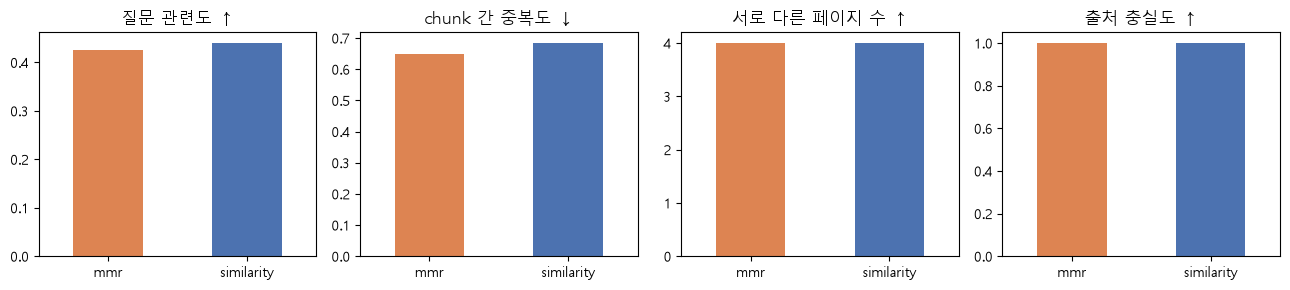

In [27]:
# 누적 파일에서 이번 실행분만 불러와 비교 (같은 셀을 다시 실행해 생긴 중복 행은 마지막 것만 남김)
log = pd.read_csv(METRICS_CSV, encoding="utf-8")
latest = (log[log.run_id == RUN_ID]
          .drop_duplicates(subset=["search_type", "question"], keep="last"))

cols = ["query_relevance", "redundancy", "n_unique_pages", "grounded"]
summary = latest.groupby("search_type")[cols].mean().round(3)
display(summary)

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
titles = {"query_relevance": "질문 관련도 ↑", "redundancy": "chunk 간 중복도 ↓",
          "n_unique_pages": "서로 다른 페이지 수 ↑", "grounded": "출처 충실도 ↑"}
for ax, (c, t) in zip(axes, titles.items()):
    summary[c].plot.bar(ax=ax, color=["#DD8452", "#4C72B0"], rot=0)
    ax.set_title(t); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "similarity_vs_mmr.png", dpi=120); plt.show()

In [28]:
# 질문별로 어떤 페이지를 가져왔고, 판정이 어땠는지 나란히 보기
display(latest.pivot(index="question", columns="search_type", values=["pages", "verdict"]))

pages  \
search_type                                                          mmr   
question                                                                   
What does Demian look like?                             [34, 54, 71, 90]   
What is Abraxas?                                    [100, 103, 110, 118]   
What is Sinclair's favorite food?                    [64, 117, 153, 175]   
Who is Franz Kromer and why is Sinclair afraid ...    [10, 43, 167, 175]   

                                                                          \
search_type                                                   similarity   
question                                                                   
What does Demian look like?                             [34, 54, 71, 90]   
What is Abraxas?                                    [100, 110, 118, 122]   
What is Sinclair's favorite food?                    [75, 117, 140, 153]   
Who is Franz Kromer and why is Sinclair afraid ...      [10, 12, 23, 43]   

                                                      verdict             
search_type                                               mmr similarity  
question                                                                  
What does Demian look like?                         SUPPORTED  SUPPORTED  
What is Abraxas?                                    SUPPORTED  SUPPORTED  
What is Sinclair's favorite food?                   SUPPORTED  SUPPORTED  
Who is Franz Kromer and why is Sinclair afraid ...  SUPPORTED  SUPPORTED

### 🧾 비교 결론
- **중복도**: mmr 0.648 < similarity 0.684로, 예상대로 mmr이 더 다양한 chunk를 가져왔습니다. 다만 차이는 0.036으로 작습니다.
- **페이지 다양성**: 둘 다 4.0입니다. 이번 설정에서는 chunk와 페이지가 1:1이라 k=4이면 항상 4페이지가 나옵니다. **이 지표는 이번 실험에서 변별력이 없었습니다.**
- **질문 관련도**: similarity 0.440 > mmr 0.426로, similarity가 약간 높습니다. mmr이 다양성을 위해 관련도를 조금 양보한 결과입니다.
- **답변 충실도**: 둘 다 1.0(전부 SUPPORTED)이라 차이를 가리지 못했습니다.
- **질문별 차이**: Demian 외모는 두 방식이 같은 페이지를 가져왔습니다. 가장 차이가 큰 것은 Kromer 질문입니다.
  - similarity는 초반부의 연속된 페이지(p.10, 12, 23, 43)를 가져왔습니다. Kromer 에피소드는 책 앞부분에 몰려 있습니다.
  - mmr은 다양성을 챙기느라 후반부 p.167·p.175를 끼워 넣었고, 실제 답변에서도 핵심 내용이 빠졌습니다.
- **이번 데이터에서 더 나은 설정: `similarity`**
  - 근거 1: chunk가 페이지 단위로 이미 커서 chunk끼리 중복이 원래 크지 않습니다. 그래서 mmr이 줄여줄 중복이 별로 없습니다.
  - 근거 2: 특정 사건을 묻는 질문은 관련 내용이 몇 페이지에 몰려 있습니다. 이 경우 mmr의 다양성 선택이 오히려 무관한 페이지를 불러옵니다.
  - mmr을 쓴다면 `lambda_mult`를 0.7 정도로 올려 관련도 쪽에 무게를 주는 편이 나아 보입니다.

---
## Step 7. 결론 · 회고

**실험 요약**
- 파이프라인: PyPDFLoader → RecursiveCharacterTextSplitter(500/50 토큰) → text-embedding-3-small → Chroma → Retriever(mmr, k=4) → RetrievalQA(gpt-4o)
- 결과
  - 182페이지가 182개 chunk로 나뉘었습니다(chunk = 페이지). 임베딩 차원은 1536, 전체 약 7.2만 토큰입니다.
  - 질문 4개 모두 출처에 근거해 답했고, 책에 없는 질문에는 "모른다"고 답했습니다.
  - search_type 비교에서는 차이가 작았지만, 사건 중심 질문(Kromer)에서 similarity가 더 적절한 페이지를 가져와 similarity를 선택했습니다.

**실패하거나 막혔던 점**
- 노트북 안의 `%pip install`이 `WinError 32`(다른 프로세스가 파일 사용 중)로 실패했습니다. 실행 중인 커널이 패키지 파일을 붙잡고 있었기 때문이며, 커널 밖(터미널)에서 `py -m pip`으로 설치해 해결했습니다.
- 설치 후에도 VS Code에 import 경고가 남았습니다. 편집기 인터프리터와 커널 파이썬이 달라서 생긴 문제였습니다.
- `chunk_size=500`이 모든 페이지보다 커서 분할이 전혀 일어나지 않았습니다. 설정 이유로 적은 "한두 문단 단위 분할"이 실제로는 적용되지 않았습니다.
- 출처 검증(LLM 판정)이 8건 모두 SUPPORTED라 두 설정의 차이를 가리지 못했습니다. `n_unique_pages`도 chunk = 페이지 구조 때문에 항상 4였습니다.

**한계**
- 질문이 4개뿐이라 비교 지표의 신뢰도가 낮습니다.
- 출처 검증을 답변을 만든 모델(gpt-4o)이 스스로 해서, 자기 답에 관대할 수 있습니다. 또 **완결성**(질문에 충분히 답했는가)은 보지 않습니다.
- 스캔본 PDF를 OCR한 텍스트라 `elc!gant`, `comP9Xed`처럼 깨진 단어가 섞여 있습니다. 임베딩과 검색 품질에 영향을 줄 수 있습니다.
- 페이지 단위로 먼저 나뉘기 때문에, 페이지 경계에서 문단이 잘립니다.

**다음 개선 방향**
- 페이지를 하나로 합친 뒤 `chunk_size` 200~300으로 나눠, 분할과 overlap이 실제로 작동하게 하기
- 판정 프롬프트에 완결성 기준 추가 (SUPPORTED + 핵심 누락 여부)
- 질문 수를 늘리고 정답 페이지를 직접 표시해 검색 정확도(hit rate)를 측정
- mmr의 `lambda_mult`(0.5 / 0.7) 비교
- 간단한 OCR 오류 정리(특수문자 제거 등) 후 검색 품질 비교
- 한국어 질문으로도 영문 문서가 검색되는지(교차언어 검색) 확인